In [53]:
import matplotlib.pyplot as plots
%matplotlib inline
plots.style.use('fivethirtyeight')

## 1 Phan vi P


In [54]:
import numpy as np
from datascience import *
s = [1,4,6,2,5]
s = np.sort(s)
percentile(85,s)

6

## 2 bootstrap

2.1 Test bootstap 1

In [55]:
population = Table.read_table('../../Data/san_francisco_2019.csv')
population

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Public Protection,Adult Probation,Information Systems,IS Trainer-Journey,91332,0,40059,131391
Public Protection,Adult Probation,Information Systems,IS Engineer-Assistant,123241,0,49279,172520
Public Protection,Adult Probation,Information Systems,IS Business Analyst-Senior,115715,0,46752,162468
Public Protection,Adult Probation,Information Systems,IS Business Analyst-Principal,159394,0,57312,216706
Public Protection,Adult Probation,Information Systems,IS Programmer Analyst,70035,0,28671,98706
Public Protection,Adult Probation,Information Systems,IS Project Director,175742,0,60830,236572
Public Protection,Adult Probation,Information Systems,IT Operations Support Admin IV,123840,0,49429,173269
Public Protection,Adult Probation,"Payroll, Billing & Accounting",Accountant III,111816,0,46319,158135
Public Protection,Adult Probation,"Budget, Admn & Stats Analysis",Statistician,87725,0,38899,126624
Public Protection,Adult Probation,"Budget, Admn & Stats Analysis",Senior Administrative Analyst,116192,0,47651,163843


In [56]:
population.sample(5,with_replacement= False) ## Lay mot bang gom 5 dong bat ky tu bang ban dau, khong hoan lai

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Culture & Recreation,Public Library,Library,Library Page,30599,0,18591,49190
General Administration & Finance,Administrative Services,Housekeeping & Laundry,Custodian,65003,5406,33804,104214
Public Protection,Police,Airport Operation,Community Police Services Aide,85385,3105,39182,127672
"Public Works, Transportation & Commerce",Public Utilities Commission,Skilled Labor,Watershed Keeper,80634,16132,38963,135729
Public Protection,Police,Police Services,Lieutenant 3,185598,20454,54300,260352


In [57]:
population.sort('Total Compensation',descending= True)


Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
General Administration & Finance,Retirement Services,Administrative & Mgmt (Unrep),Chief Investment Officer,577633,0,146398,724031
General Administration & Finance,Retirement Services,Unassigned,Managing Director,483072,0,134879,617951
General Administration & Finance,Retirement Services,Unassigned,Managing Director,482649,0,134905,617554
General Administration & Finance,Retirement Services,Unassigned,Managing Director,451507,0,120276,571784
General Administration & Finance,Retirement Services,Unassigned,Managing Director,449378,0,120857,570235
Community Health,Public Health,Administrative & Mgmt (Unrep),"Physician Administrator, DPH",434966,0,119213,554179
Public Protection,Sheriff,Correction & Detention,Senior Deputy Sheriff,152153,315896,77275,545324
General Administration & Finance,Retirement Services,Management,Director,397392,0,108913,506305
Community Health,Public Health,Medical & Dental,Supervising Physician Spec,404701,0,99480,504181
Community Health,Public Health,Medical & Dental,Senior Physician Specialist,400992,0,97428,498421


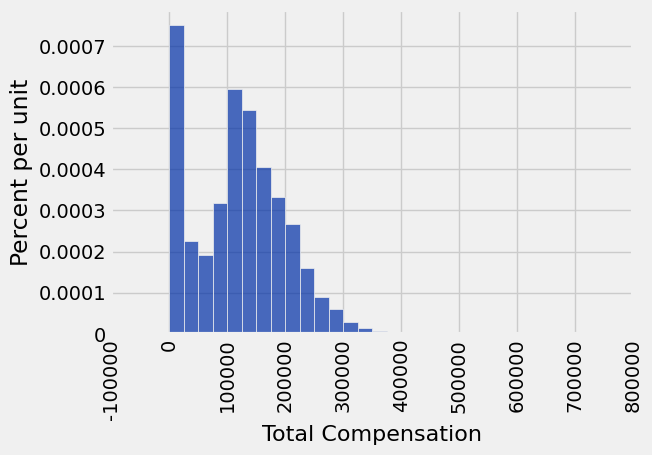

In [58]:
population.hist('Total Compensation', bins = np.arange(0,726000,25000))


In [59]:
minsalary = 15*20*50
population = population.where('Salary', are.above(minsalary))
population

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Public Protection,Adult Probation,Information Systems,IS Trainer-Journey,91332,0,40059,131391
Public Protection,Adult Probation,Information Systems,IS Engineer-Assistant,123241,0,49279,172520
Public Protection,Adult Probation,Information Systems,IS Business Analyst-Senior,115715,0,46752,162468
Public Protection,Adult Probation,Information Systems,IS Business Analyst-Principal,159394,0,57312,216706
Public Protection,Adult Probation,Information Systems,IS Programmer Analyst,70035,0,28671,98706
Public Protection,Adult Probation,Information Systems,IS Project Director,175742,0,60830,236572
Public Protection,Adult Probation,Information Systems,IT Operations Support Admin IV,123840,0,49429,173269
Public Protection,Adult Probation,"Payroll, Billing & Accounting",Accountant III,111816,0,46319,158135
Public Protection,Adult Probation,"Budget, Admn & Stats Analysis",Statistician,87725,0,38899,126624
Public Protection,Adult Probation,"Budget, Admn & Stats Analysis",Senior Administrative Analyst,116192,0,47651,163843


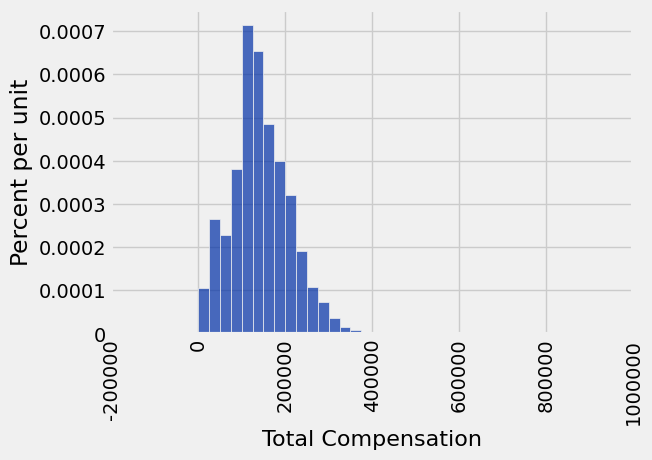

In [60]:
population.hist('Total Compensation', bins = np.arange(0,800000,25000))

In [61]:
unknown_median = percentile(50,population.column('Total Compensation')) # median cua population
unknown_median

135747.0

In [62]:
a_sample = population.sample(500,with_replacement= False)
a_sample

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
General Administration & Finance,Treasurer/Tax Collector,"Budget, Admn & Stats Analysis",Pr Administrative Analyst,129835,0,50275,180110
Community Health,Public Health,Nursing,Patient Care Assistant,62725,12388,33671,108784
"Public Works, Transportation & Commerce",Municipal Transportation Agcy,Journeyman Trade,Electronic Maintenance Tech,134186,45718,55714,235619
"Public Works, Transportation & Commerce",Municipal Transportation Agcy,Street Transit,Transit Operator,77492,467,37331,115291
"Public Works, Transportation & Commerce",Municipal Transportation Agcy,Street Transit,Transit Operator,93518,112001,47692,253211
General Administration & Finance,Assessor,Management,Manager II,116417,0,47022,163439
Community Health,Public Health,"Lab, Pharmacy & Med Techs",Pharmacist,179170,0,60520,239691
Public Protection,Police,Police Services,Police Officer 3,141869,74406,46745,263020
Public Protection,Police,Airport Operation,Community Police Services Aide,80912,963,37514,119390
Community Health,Public Health,Nursing,Patient Care Assistant,74141,1474,34374,109989


In [63]:
sf_bins = np.arange(0, 726000, 25000)
bootstrap_sample = a_sample.sample()
print(bootstrap_sample)
percentile(50,bootstrap_sample.column('Total Compensation'))

Organization Group                       | Department                     | Job Family                   | Job                         | Salary | Overtime | Benefits | Total Compensation
Community Health                         | Public Health                  | Housekeeping & Laundry       | Porter                      | 62598  | 0        | 32162    | 94760
Public Works, Transportation & Commerce  | Municipal Transportation Agcy  | Street Transit               | Transit Operator            | 76285  | 17187    | 37308    | 130780
Culture & Recreation                     | Recreation And Park Commission | Recreation                   | Recreation Leader           | 25874  | 0        | 436      | 26311
Human Welfare & Neighborhood Development | Human Services                 | Human Services               | Protective Services Worker  | 110435 | 0        | 46019    | 156454
Public Protection                        | Dept of Police Accountablility | Legal & Court                | Attorney

131777.0

In [64]:
def one_bootstrap_median():
    re_sample = a_sample.sample()
    return percentile(50,re_sample.column('Total Compensation'))
one_bootstrap_median()

133232.0

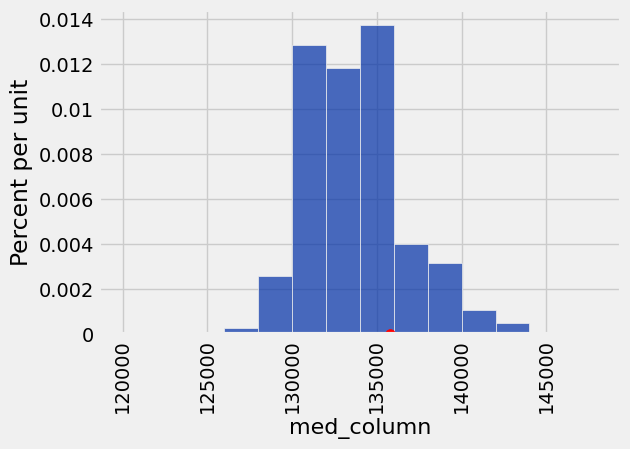

In [65]:
repitition = 5000
median_sample = make_array()

for i in np.arange(5000):
    med = one_bootstrap_median()
    median_sample = np.append(median_sample,med)

result = Table().with_column(
    'med_column', median_sample
).hist(bins = np.arange(120000,150000,2000))
plots.scatter(unknown_median,0, color = 'red', s = 50, zorder = 2)
plots.show()

Mo phong cac khoang uoc luong

In [66]:
def one_simulated():
    repitition = 5000
    median_sample = make_array()
    for i in np.arange(repitition):
        med = one_bootstrap_median()
        median_sample = np.append(median_sample,med)
    return median_sample
one_simulated()


array([ 132864.,  131536.,  133232., ...,  135589.,  135921.,  135589.])

In [67]:
# left = make_array()
# right = make_array()
# for i in np.arange(50):
#     med_array = one_simulated()
#     left = np.append(left,percentile(2.5,med_array))
#     right = np.append(right,percentile(97.5,med_array))
# table_med = Table().with_columns(
#     'left',left,
#     'right', right
# )
# table_med

Mo phong phuong phap phan vi bootstrap

In [68]:
births = Table().read_table('../../Data/baby.csv')
births

Unnamed: 0,Birth.Weight,Gestational.Days,Maternal.Age,Maternal.Height,Maternal.Pregnancy.Weight,Maternal.Smoker
1,120,284,27,62,100,False
2,113,282,33,64,135,False
3,128,279,28,64,115,True
4,108,282,23,67,125,True
5,136,286,25,62,93,False
6,138,244,33,62,178,False
7,132,245,23,65,140,False
8,120,289,25,62,125,False
9,143,299,30,66,136,True
10,140,351,27,68,120,False


In [69]:
ratios = births.select('Birth.Weight','Gestational.Days').with_column(
    'Ratios BW:GD',births.column('Birth.Weight')/births.column('Gestational.Days')
)
ratios

Birth.Weight,Gestational.Days,Ratios BW:GD
120,284,0.422535
113,282,0.400709
128,279,0.458781
108,282,0.382979
136,286,0.475524
138,244,0.565574
132,245,0.538776
120,289,0.415225
143,299,0.478261
140,351,0.39886


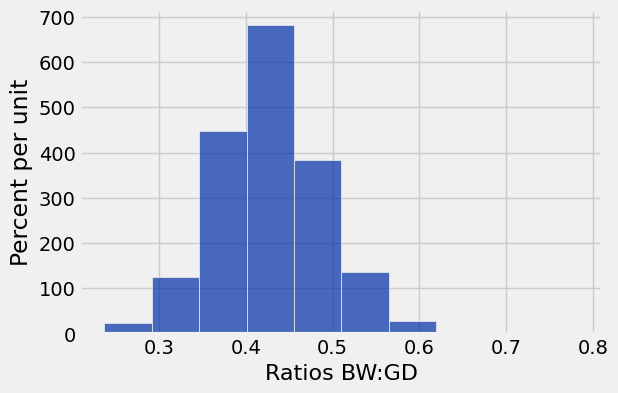

In [70]:
ratios.hist('Ratios BW:GD')

In [71]:
percentile(50,ratios.column('Ratios BW:GD'))

0.42907801418439717

In [72]:
def one_simulation():
    bootstrap_sample = ratios.sample()
    return percentile(50,bootstrap_sample.column('Ratios BW:GD'))
one_simulation()

0.42753623188405798

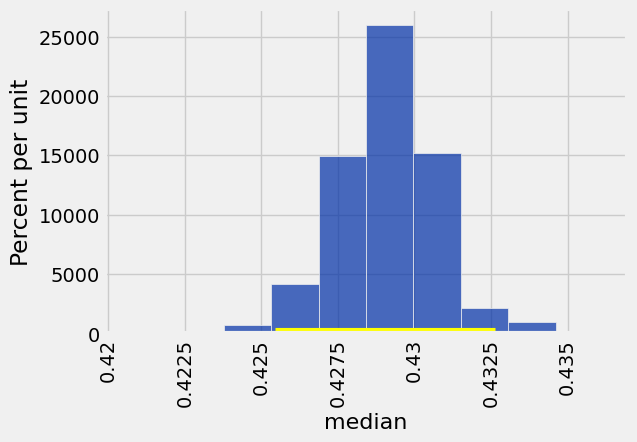

In [73]:
repitition = 5000
interval = make_array()
for i in np.arange(repitition):
    value = one_simulation()
    interval = np.append(interval,value)
table1 = Table().with_column(
    'median', interval
)
left = percentile(2.5,interval)
right = percentile(97.5,interval)
table1.hist()
plots.plot([left,right],[0,0],color = 'yellow',lw = 8)

Uoc tinh tuoi trung binh cua cac ba me

In [113]:
age = births.select('Maternal.Age')
age


Maternal.Age
27
33
28
23
25
33
23
25
30
27


In [99]:
def one_bootstrap_average():
    bootstrap_average = age.sample()
    return np.average(bootstrap_average.column('Maternal.Age'))
one_bootstrap_average()

26.896081771720613

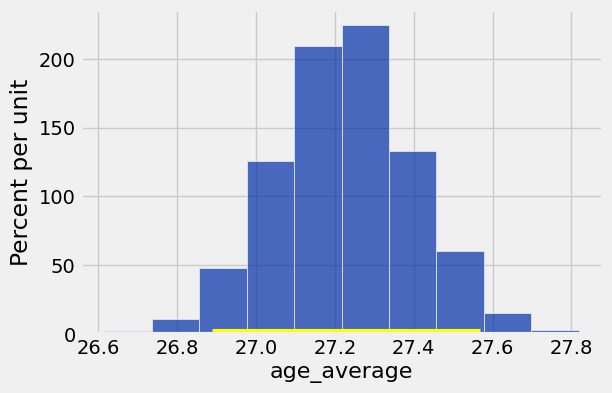

In [100]:
repitition = 5000
bootstrap_array = make_array()
for i in np.arange(repitition):
    bootstrap_array = np.append(bootstrap_array,one_bootstrap_average())
left = percentile(2.5,bootstrap_array)
right = percentile(97.5,bootstrap_array)
result = Table().with_column(
    'age_average',bootstrap_array
)
result.hist()
plots.plot([left,right],[0,0], color = 'yellow',lw =8)

Su dung uoc luong de kiem dinh gia thuyet
Gia thuyet 0: muc giam trung binh la 0
Gia thuyet thay the : muc giam trung binh khong phai la 0

In [101]:
hodgkins =Table.read_table("../../Data/hodgkins.csv")
hodgkins

height,rad,chemo,base,month15
164,679,180,160.57,87.77
168,311,180,98.24,67.62
173,388,239,129.04,133.33
157,370,168,85.41,81.28
160,468,151,67.94,79.26
170,341,96,150.51,80.97
163,453,134,129.88,69.24
175,529,264,87.45,56.48
185,392,240,149.84,106.99
178,479,216,92.24,73.43


In [102]:
np.average(hodgkins.column('base') - hodgkins.column('month15'))

28.615909090909096

In [108]:
def one_simulation_hodgkins():
    hodgkins_sample = hodgkins.sample()
    return np.average(hodgkins_sample.column('base') - hodgkins_sample.column('month15'))
one_simulation_hodgkins()

29.497272727272719

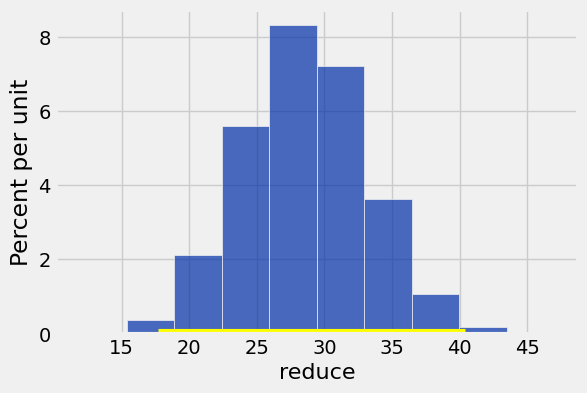

In [112]:
repitition = 10000
hodgkins_array = make_array()

for i in np.arange(repitition):
    value = one_simulation_hodgkins()
    hodgkins_array = np.append(hodgkins_array,value)
left = percentile(0.5,hodgkins_array)
right = percentile(99.5,hodgkins_array)
hodgkins_table = Table().with_column(
    'reduce',hodgkins_array
)
hodgkins_table.hist()
plots.plot([left,right],[0,0],color = 'yellow',lw = 8)


